In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# DATA INSPECTION

df =pd.read_csv("./data/heart_disease_uci.csv")
df

In [7]:
get_header=[col for col in df.columns]
print(get_header)

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target']


In [ ]:
print(df.shape)
print(df.shape)
print(df.info())

In [ ]:
# CHECK MISSING VALUES
print(df.isnull().sum())

In [25]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


## CHAP 1.0  UNIVARIATE ANALYSIS:
Skewness: Only measurements (age, chol, bp

Skewness Candidates: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical Signals: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']


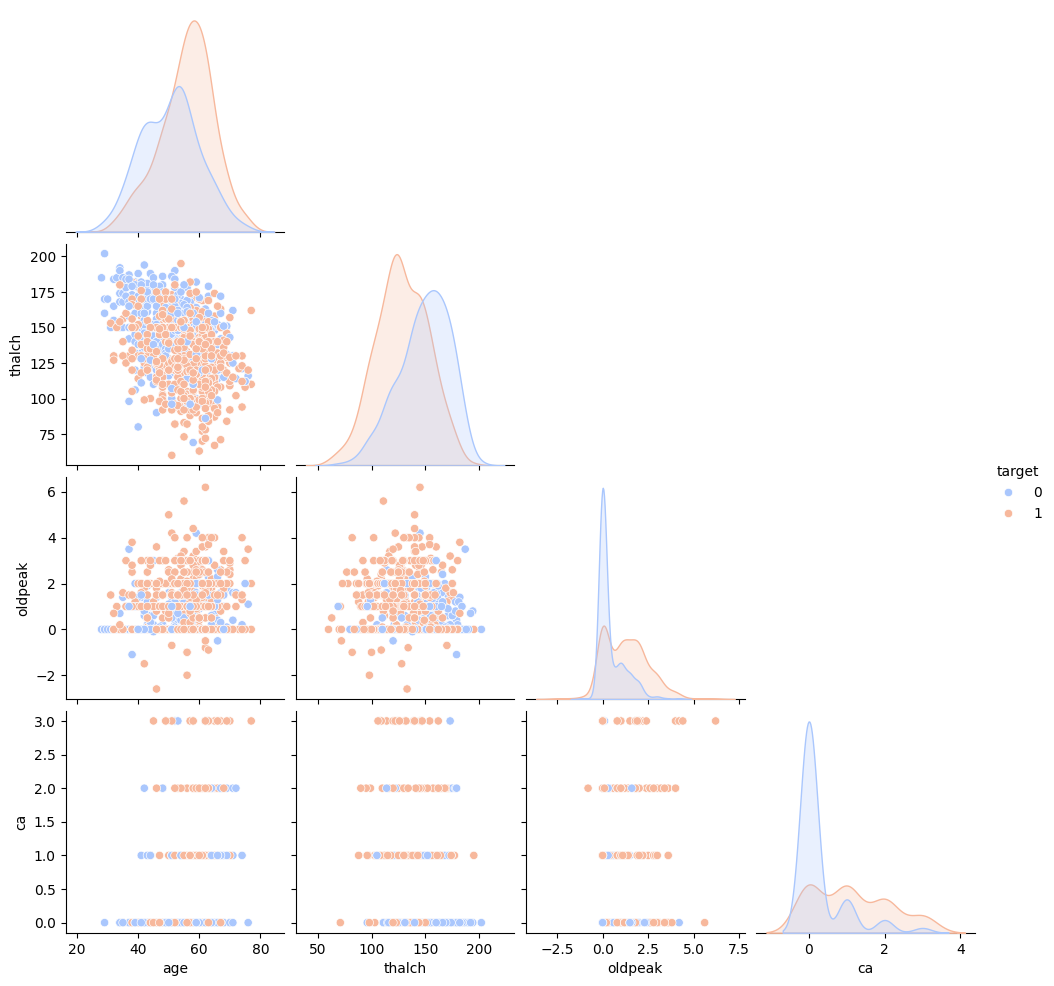

In [18]:
continuous_vars = [col for col in df.columns if df[col].nunique() > 10]
print(f"Skewness Candidates: {continuous_vars}")

# 2. IDENTIFY CATEGORICAL VARIABLES (For Bivariate/One-Hot Encoding)
categorical_vars = [col for col in df.columns if df[col].nunique() <= 10 and col != 'target']
print(f"Categorical Signals: {categorical_vars}")

# --- THE SKEWNESS TEST ---
for col in continuous_vars:
    skew_val = df[col].skew()
    if abs(skew_val) > 0.75:
        print(f"WARNING: {col} is skewed ({skew_val:.2f}). Needs transformation!")

# --- THE MULTIVARIATE SEARCH ---
# Let's pick the top 3 continuous vars and top 3 categorical vars 
# to see how they interact with the target.
top_vars = ['age', 'thalch', 'oldpeak', 'cp', 'ca', 'thal']
sns.pairplot(df[top_vars + ['target']], hue='target', corner=True, palette='coolwarm')
plt.show()

<Axes: xlabel='num', ylabel='Count'>

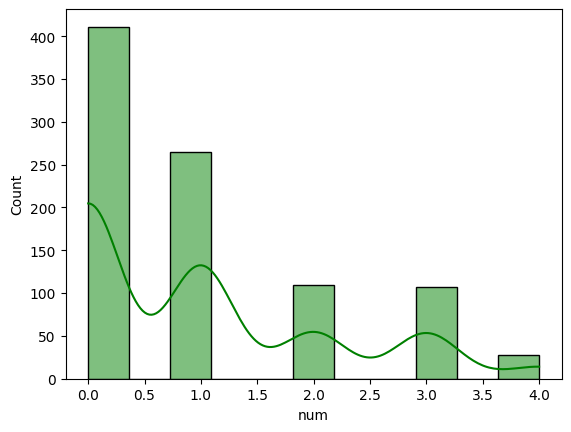

In [4]:
sns.histplot(df['num'], kde=True, color="green")

In [5]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


In [6]:
import pandas as pd
df["target"]=(df["num"]>0).astype(int)
print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


## Part 3: Bivariate Analysis — feature by feature, against the target

Bivariate analysis means: for every single feature, does it look different between the "disease" group and the "no disease" group? If a feature's distribution is identical in both groups, it carries no signal — the model can't use it to tell the groups apart. If it's clearly different, it's a candidate predictor. The method is different depending on whether the feature is numeric or categorical, so I'll do both, one at a time, and tell you exactly why we read each plot the way we do.

## 3.1 Numeric features vs target

For a numeric feature, the right question is: "if I look at all the diseased patients' values for this feature, and separately all the healthy patients' values, are those two distributions in different places?" The tool for this is overlaid histograms or grouped box plots — both show you the same thing in different ways. A histogram shows the full shape (is it skewed, bimodal, etc.); a box plot shows the median and spread quickly side-by-side. I'll do both because each catches something the other misse

In [27]:
# df["target"]=(df["num"]>0).astype(int)
print(df["target"].value_counts())

target
1    509
0    411
Name: count, dtype: int64


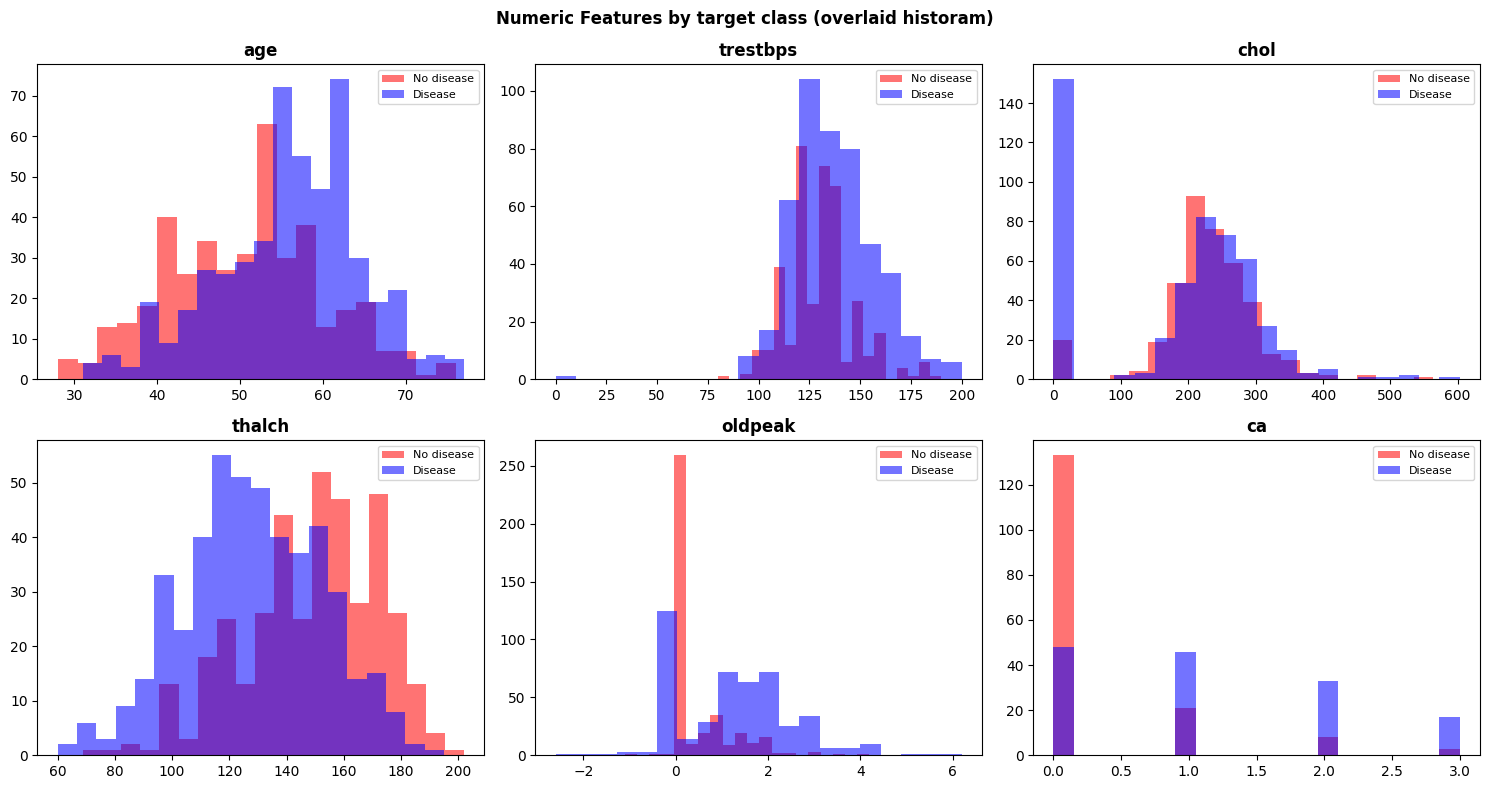

In [28]:
num_cols=["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes=plt.subplots(2,3, figsize=(15, 8))
axes=axes.flatten()


# use the  for loop to plot for each numerical feature
for i, col in enumerate(num_cols):
    for label, color, name in ((0, "red", "No disease"), (1, "blue", "Disease")):
        subset=df[df['target']==label][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.55, label=name, color=color)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Numeric Features by target class (overlaid historam)', fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_vs_target_hists.png', dpi=130)
    

        


## 3.2 Categorical features vs target

For a categorical feature there's no "median" or "histogram shape" — there's no number line for "asymptomatic" to sit on. So the right tool is different: for each category, what percentage of patients in that category have disease? If that percentage is roughly the same across all categories of a feature, the feature tells you nothing. If it swings a lot between categories, the feature is informative.

Selection deleted


In [31]:
cat_cols=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']
fig, axes=plt.subplots(2, 4, figsize=(10, 9))
axes=axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()
    rate.plot(kind='bar', ax=axes[i], color='#1E5FA8', edgecolor='white')
    axes[i].axhline(df['target'].mean(), color='red', linestyle='--', label=f'Overall rate: {df["target"].mean():.2f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('% with disease')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=40)
plt.suptitle('Disease Rate by Category (red line = overall average rate)', fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_vs_targets.png', dpi=130)
plt.close()

![image.png](attachment:4ee6637a-f777-4dce-8a98-125a549559d8.png)

In [ ]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Matrix (numeric features + target)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=130)
plt.close()
print(corr['target'].sort_values(ascending=False))

## Part 6: Missing Data Audit — what's actually missing, and what to do about each column

Recall the missing-value counts from earlier##



In [33]:
miss = df.isnull().sum()
pct = (100*miss/len(df)).round(1)
report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
report = report[report.missing_count > 0].sort_values('missing_pct', ascending=False)
print(report)
print()
print('zeros in chol:', (df['chol']==0).sum())
print('zeros in trestbps:', (df['trestbps']==0).sum())

          missing_count  missing_pct
ca                  611         66.4
thal                486         52.8
slope               309         33.6
fbs                  90          9.8
oldpeak              62          6.7
trestbps             59          6.4
exang                55          6.0
thalch               55          6.0
chol                 30          3.3
restecg               2          0.2

zeros in chol: 172
zeros in trestbps: 1


In [34]:
print('chol==0 rows by hospital:')
print(df[df['chol']==0]['dataset'].value_counts())
print()
print('trestbps==0 rows by hospital:')
print(df[df['trestbps']==0]['dataset'].value_counts())

chol==0 rows by hospital:
dataset
Switzerland      123
VA Long Beach     49
Name: count, dtype: int64

trestbps==0 rows by hospital:
dataset
VA Long Beach    1
Name: count, dtype: int64


In [35]:
# Step 0: build the target, drop the leakage-prone / non-feature columns
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['id', 'num', 'dataset'])

# id -> just a row index, not a feature
# num -> replaced by target, would leak the answer if kept
# dataset -> hospital-site artifact, explained in Part 3 + Part 6.1



In [37]:
# Step 1: convert biologically-impossible zeros to NaN (chol, trestbps)
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)


# Step 2: drop ca and thal — too much hospital-driven missingness (>60%)
df = df.drop(columns=['ca', 'thal'])

# Step 3: impute slope (33.6% missing, kept) with most frequent category
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

# Step 4: impute remaining small-gap numeric columns with median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col] = df[col].fillna(df[col].median())

# Step 5: impute remaining small-gap categorical/boolean columns with mode
for col in ['fbs', 'restecg', 'exang']:
    df[col] = df[col].fillna(df[col].mode()[0])




KeyError: "['ca', 'thal'] not found in axis"

In [38]:
print("Missing values remaining:")
print(df.isnull().sum().sum())
print()
print("Final columns:", df.columns.tolist())
print()
print(df.head(3))

Missing values remaining:
0

Final columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'target']

   age   sex              cp  trestbps   chol    fbs         restecg  thalch  \
0   63  Male  typical angina     145.0  233.0   True  lv hypertrophy   150.0   
1   67  Male    asymptomatic     160.0  286.0  False  lv hypertrophy   108.0   
2   67  Male    asymptomatic     120.0  229.0  False  lv hypertrophy   129.0   

   exang  oldpeak        slope  target  
0  False      2.3  downsloping       0  
1   True      1.5         flat       1  
2   True      2.6         flat       1  
